# Gradient Boosting Notebook
## Kaggle Irrigation Competition
### Dirks Wright


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier

RANDOM_STATE = 222

In [6]:
# Load the same Kaggle data used in HW_2_Kaggle
df = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

print("Train shape:", df.shape)
print("Test shape:", df_test.shape)
display(df.head())

target_col = "Irrigation_Need"
id_col = "id"

# Encode categories using the combined train+test values so test labels are always seen.
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
if target_col in categorical_cols:
    categorical_cols.remove(target_col)

label_encoders = {}
for col in categorical_cols:
    encoder = LabelEncoder()
    combined_values = pd.concat([df[col].astype(str), df_test[col].astype(str)], axis=0)
    encoder.fit(combined_values)
    df[col] = encoder.transform(df[col].astype(str))
    df_test[col] = encoder.transform(df_test[col].astype(str))
    label_encoders[col] = encoder

target_encoder = LabelEncoder()
df[target_col] = target_encoder.fit_transform(df[target_col])

X_full = df.drop(columns=[id_col, target_col])
y_full = df[target_col]
X_test = df_test.drop(columns=[id_col])

# Use a stratified sample for faster hyperparameter exploration.
search_df, _ = train_test_split(
    df,
    train_size=0.80,
    stratify=df[target_col],
    random_state=RANDOM_STATE,
)

X_search = search_df.drop(columns=[id_col, target_col])
y_search = search_df[target_col]

X_search_train, X_search_val, y_search_train, y_search_val = train_test_split(
    X_search,
    y_search,
    test_size=0.20,
    stratify=y_search,
    random_state=RANDOM_STATE,
)

X_train_full, X_val_full, y_train_full, y_val_full = train_test_split(
    X_full,
    y_full,
    test_size=0.20,
    stratify=y_full,
    random_state=RANDOM_STATE,
)

print("\nSample used for hyperparameter experiments:")
print(X_search_train.shape, X_search_val.shape)
print("\nFull split used for final comparison:")
print(X_train_full.shape, X_val_full.shape)
print("\nClass labels:", list(target_encoder.classes_))

Train shape: (630000, 21)
Test shape: (270000, 20)


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low



Sample used for hyperparameter experiments:
(403200, 19) (100800, 19)

Full split used for final comparison:
(504000, 19) (126000, 19)

Class labels: ['High', 'Low', 'Medium']


In [7]:
experiment_configs = {}
search_results = []
trained_search_models = {}

def run_search_experiment(config):
    label = config["label"]
    experiment_configs[label] = config
    search_results[:] = [
        row for row in search_results
        if row["Configuration"] != label
    ]

    model = config["model"]
    model.fit(X_search_train, y_search_train)
    preds = model.predict(X_search_val)
    trained_search_models[label] = model

    result_row = {
        "Algorithm": config["algorithm"],
        "Configuration": label,
        "Validation Accuracy": accuracy_score(y_search_val, preds),
        "Validation F1 (Weighted)": f1_score(y_search_val, preds, average="weighted"),
        "Notes": config["notes"],
    }
    search_results.append(result_row)

    display(pd.DataFrame([result_row]).style.format({
        "Validation Accuracy": "{:.4f}",
        "Validation F1 (Weighted)": "{:.4f}",
    }))


In [8]:
run_search_experiment({
    "algorithm": "GradientBoostingClassifier",
    "label": "GBM Baseline",
    "model": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    "notes": "Default settings from scikit-learn.",
})

,Algorithm,Configuration,Validation Accuracy,Validation F1 (Weighted),Notes
0,GradientBoostingClassifier,GBM Baseline,0.9850,0.9849,Default settings from scikit-learn.


In [9]:
### first set of hyperparameter tuning experiments for GradientBoostingClassifier
run_search_experiment({
    "algorithm": "GradientBoostingClassifier",
    "label": "GBM Tuned",
    "model": GradientBoostingClassifier(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
    ),
    "notes": "More trees, lower learning rate, and row subsampling.",
})

,Algorithm,Configuration,Validation Accuracy,Validation F1 (Weighted),Notes
0,GradientBoostingClassifier,GBM Tuned,0.9852,0.9851,"More trees, lower learning rate, and row subsampling."


In [10]:
### second set of hyperparameter tuning experiments for GradientBoostingClassifier
run_search_experiment({
    "algorithm": "GradientBoostingClassifier",
    "label": "GBM Conservative",
    "model": GradientBoostingClassifier(
        n_estimators=400,
        learning_rate=0.02,
        max_depth=2,
        subsample=0.7,
        min_samples_leaf=10,
        random_state=RANDOM_STATE,
    ),
    "notes": "Smaller steps and shallower trees to test underfitting.",
})

,Algorithm,Configuration,Validation Accuracy,Validation F1 (Weighted),Notes
0,GradientBoostingClassifier,GBM Conservative,0.9606,0.9564,Smaller steps and shallower trees to test underfitting.


In [15]:
### third set of hyperparameter tuning experiments for GradientBoostingClassifier
run_search_experiment({
    "algorithm": "GradientBoostingClassifier", 
    "label": "GBM Aggressive",
    "model": GradientBoostingClassifier(
        n_estimators=50,
        learning_rate=0.01,
        max_depth=5,
        subsample=1.0,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
    ),
    "notes": "Less trees, deeper, and no regularization to test overfitting.",
})



,Algorithm,Configuration,Validation Accuracy,Validation F1 (Weighted),Notes
0,GradientBoostingClassifier,GBM Aggressive,0.9423,0.9316,"Less trees, deeper, and no regularization to test overfitting."


In [11]:
run_search_experiment({
    "algorithm": "CatBoostClassifier",
    "label": "CatBoost Baseline",
    "model": CatBoostClassifier(
        iterations=150,
        learning_rate=0.10,
        depth=6,
        loss_function="MultiClass",
        eval_metric="TotalF1",
        random_seed=RANDOM_STATE,
        verbose=0,
    ),
    "notes": "CatBoost baseline with multiclass loss and default-style tree depth.",
})

,Algorithm,Configuration,Validation Accuracy,Validation F1 (Weighted),Notes
0,CatBoostClassifier,CatBoost Baseline,0.9844,0.9843,CatBoost baseline with multiclass loss and default-style tree depth.


In [12]:
### first set of hyperparameter tuning experiments for CatBoost
run_search_experiment({
    "algorithm": "CatBoostClassifier",
    "label": "CatBoost Tuned",
    "model": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=8,
        l2_leaf_reg=3.0,
        random_strength=1.0,
        loss_function="MultiClass",
        eval_metric="TotalF1",
        random_seed=RANDOM_STATE,
        verbose=0,
    ),
    "notes": "More trees and a lower learning rate for a smoother CatBoost fit.",
})

,Algorithm,Configuration,Validation Accuracy,Validation F1 (Weighted),Notes
0,CatBoostClassifier,CatBoost Tuned,0.9845,0.9844,More trees and a lower learning rate for a smoother CatBoost fit.


In [13]:
### second set of hyperparameter tuning experiments for CatBoost
run_search_experiment({
    "algorithm": "CatBoostClassifier",
    "label": "CatBoost Conservative",
    "model": CatBoostClassifier(
        iterations=500,
        learning_rate=0.02,
        depth=3,
        l2_leaf_reg=10.0,
        random_strength=3.0,
        loss_function="MultiClass",
        eval_metric="TotalF1",
        random_seed=RANDOM_STATE,
        verbose=0,
    ),
    "notes": "Heavier regularization and shallower trees to test underfitting.",
})

,Algorithm,Configuration,Validation Accuracy,Validation F1 (Weighted),Notes
0,CatBoostClassifier,CatBoost Conservative,0.9827,0.9826,Heavier regularization and shallower trees to test underfitting.


In [16]:
### third set of hyperparameter tuning experiments for catboost
run_search_experiment({
    "algorithm": "CatBoostClassifier",
    "label": "CatBoost Aggressive",
    "model": CatBoostClassifier(
        iterations=200,
        learning_rate=0.01,
        depth=10,
        l2_leaf_reg=1.0,
        random_strength=0.5,
        loss_function="MultiClass",
        eval_metric="TotalF1",
        random_seed=RANDOM_STATE,
        verbose=0,
    ),
    "notes": "Less trees, deeper, and less regularization to test overfitting.",
})

,Algorithm,Configuration,Validation Accuracy,Validation F1 (Weighted),Notes
0,CatBoostClassifier,CatBoost Aggressive,0.9844,0.9843,"Less trees, deeper, and less regularization to test overfitting."


In [17]:
results_df = pd.DataFrame(search_results).sort_values(
    by="Validation F1 (Weighted)",
    ascending=False,
).reset_index(drop=True)

display(results_df.style.format({
    "Validation Accuracy": "{:.4f}",
    "Validation F1 (Weighted)": "{:.4f}",
}))

,Algorithm,Configuration,Validation Accuracy,Validation F1 (Weighted),Notes
0,GradientBoostingClassifier,GBM Tuned,0.9852,0.9851,"More trees, lower learning rate, and row subsampling."
1,GradientBoostingClassifier,GBM Baseline,0.9850,0.9849,Default settings from scikit-learn.
2,CatBoostClassifier,CatBoost Tuned,0.9845,0.9844,More trees and a lower learning rate for a smoother CatBoost fit.
3,CatBoostClassifier,CatBoost Baseline,0.9844,0.9843,CatBoost baseline with multiclass loss and default-style tree depth.
4,CatBoostClassifier,CatBoost Aggressive,0.9844,0.9843,"Less trees, deeper, and less regularization to test overfitting."
5,CatBoostClassifier,CatBoost Conservative,0.9827,0.9826,Heavier regularization and shallower trees to test underfitting.
6,GradientBoostingClassifier,GBM Conservative,0.9606,0.9564,Smaller steps and shallower trees to test underfitting.
7,GradientBoostingClassifier,GBM Aggressive,0.9423,0.9316,"Less trees, deeper, and no regularization to test overfitting."


,Algorithm,Best Configuration,Best Weighted F1,Worst Configuration,Worst Weighted F1,Spread
0,CatBoostClassifier,CatBoost Tuned,0.9844,CatBoost Conservative,0.9826,0.0018
1,GradientBoostingClassifier,GBM Tuned,0.9851,GBM Aggressive,0.9316,0.0535


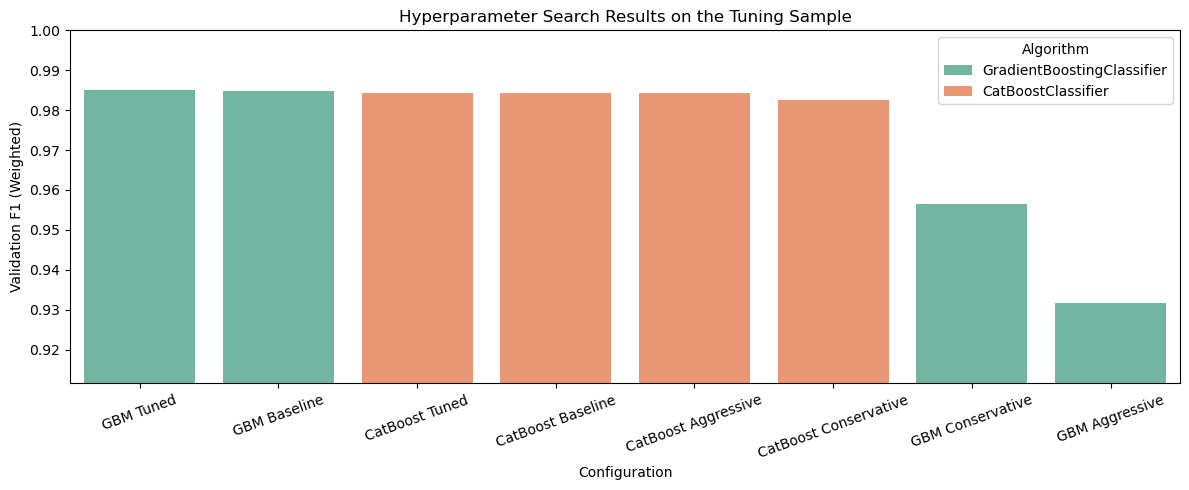

Key takeaway:
Large parameter changes can absolutely move model quality. Conservative settings were useful because they made underfitting visible.


In [18]:
# Compare each algorithm against its own best setting.
algorithm_summary = []
for algorithm_name, group in results_df.groupby("Algorithm"):
    best_row = group.iloc[group["Validation F1 (Weighted)"].argmax()]
    worst_row = group.iloc[group["Validation F1 (Weighted)"].argmin()]
    algorithm_summary.append({
        "Algorithm": algorithm_name,
        "Best Configuration": best_row["Configuration"],
        "Best Weighted F1": best_row["Validation F1 (Weighted)"],
        "Worst Configuration": worst_row["Configuration"],
        "Worst Weighted F1": worst_row["Validation F1 (Weighted)"],
        "Spread": best_row["Validation F1 (Weighted)"] - worst_row["Validation F1 (Weighted)"],
    })

algorithm_summary_df = pd.DataFrame(algorithm_summary)
display(algorithm_summary_df.style.format({
    "Best Weighted F1": "{:.4f}",
    "Worst Weighted F1": "{:.4f}",
    "Spread": "{:.4f}",
}))

plt.figure(figsize=(12, 5))
sns.barplot(
    data=results_df,
    x="Configuration",
    y="Validation F1 (Weighted)",
    hue="Algorithm",
    palette="Set2",
)
plt.xticks(rotation=20)
plt.ylim(results_df["Validation F1 (Weighted)"].min() - 0.02, 1.0)
plt.title("Hyperparameter Search Results on the Tuning Sample")
plt.tight_layout()
plt.show()

print("Key takeaway:")
print("Large parameter changes can absolutely move model quality. Conservative settings were useful because they made underfitting visible.")

In [19]:
# Refit the best configuration from each algorithm on the full train split.
best_configs = {}
for algorithm_name, group in results_df.groupby("Algorithm"):
    best_label = group.sort_values("Validation F1 (Weighted)", ascending=False).iloc[0]["Configuration"]
    best_configs[algorithm_name] = experiment_configs[best_label]

final_results = []
final_models = {}

for algorithm_name, config in best_configs.items():
    model = config["model"]
    model.fit(X_train_full, y_train_full)
    preds = model.predict(X_val_full)
    final_models[algorithm_name] = model
    final_results.append({
        "Algorithm": algorithm_name,
        "Configuration": config["label"],
        "Validation Accuracy": accuracy_score(y_val_full, preds),
        "Validation F1 (Weighted)": f1_score(y_val_full, preds, average="weighted"),
        "Validation F1 (Macro)": f1_score(y_val_full, preds, average="macro"),
    })

final_results_df = pd.DataFrame(final_results).sort_values(
    by="Validation F1 (Weighted)",
    ascending=False,
).reset_index(drop=True)

display(final_results_df.style.format({
    "Validation Accuracy": "{:.4f}",
    "Validation F1 (Weighted)": "{:.4f}",
    "Validation F1 (Macro)": "{:.4f}",
}))

best_overall_algorithm = final_results_df.iloc[0]["Algorithm"]
best_overall_model = final_models[best_overall_algorithm]
best_overall_preds = best_overall_model.predict(X_val_full)

print(f"Best overall algorithm: {best_overall_algorithm}")
print(classification_report(
    y_val_full,
    best_overall_preds,
    target_names=target_encoder.classes_,
))

,Algorithm,Configuration,Validation Accuracy,Validation F1 (Weighted),Validation F1 (Macro)
0,GradientBoostingClassifier,GBM Tuned,0.9852,0.9852,0.9711
1,CatBoostClassifier,CatBoost Tuned,0.9849,0.9848,0.9702


Best overall algorithm: GradientBoostingClassifier
              precision    recall  f1-score   support

        High       0.98      0.91      0.94      4202
         Low       0.99      1.00      0.99     73983
      Medium       0.99      0.98      0.98     47815

    accuracy                           0.99    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.99      0.99      0.99    126000



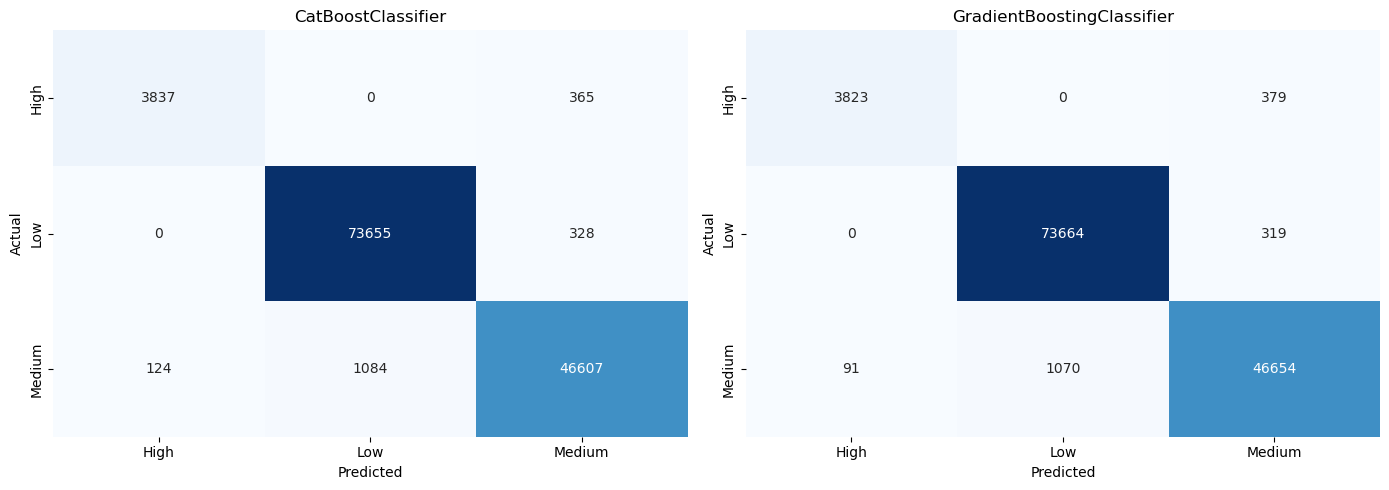

,Feature,Importance
2,Soil_Moisture,0.336485
11,Crop_Growth_Stage,0.330526
16,Mulching_Used,0.098130
5,Temperature_C,0.095868
9,Wind_Speed_kmh,0.093542
7,Rainfall_mm,0.044228
17,Previous_Irrigation_mm,0.000954
1,Soil_pH,0.000111
14,Water_Source,0.000064
4,Electrical_Conductivity,0.000041


C:\Users\Dirks Wright\AppData\Local\Temp\ipykernel_26808\2112404847.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


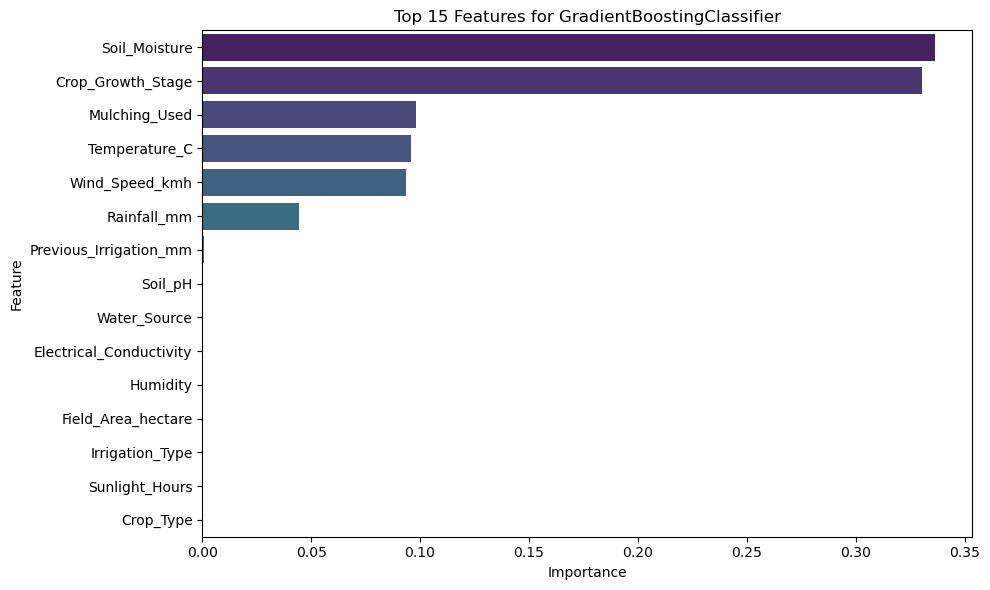

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (algorithm_name, model) in zip(axes, final_models.items()):
    preds = model.predict(X_val_full)
    cm = confusion_matrix(y_val_full, preds)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        cbar=False,
        xticklabels=target_encoder.classes_,
        yticklabels=target_encoder.classes_,
    )
    ax.set_title(algorithm_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

feature_importance = pd.DataFrame({
    "Feature": X_train_full.columns,
    "Importance": best_overall_model.feature_importances_,
}).sort_values("Importance", ascending=False)

display(feature_importance.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature",
    palette="viridis",
)
plt.title(f"Top 15 Features for {best_overall_algorithm}")
plt.tight_layout()
plt.show()

In [21]:
# Train the best overall model on all available training rows and create a Kaggle submission file.
submission_dfs = {}

for algorithm_name, config in best_configs.items():
    model = config["model"]
    model.fit(X_full, y_full)

    test_predictions = model.predict(X_test)
    decoded_predictions = target_encoder.inverse_transform(test_predictions)

    submission_df = pd.DataFrame({
        "id": df_test[id_col],
        target_col: decoded_predictions,
    })

    filename = f"{algorithm_name.lower()}_best_submission.csv"
    submission_df.to_csv(filename, index=False)
    submission_dfs[algorithm_name] = submission_df

    print(f"Saved submission for {algorithm_name} to {filename}")
    display(submission_df.head(10))

Saved submission for CatBoostClassifier to catboostclassifier_best_submission.csv


c:\Users\Dirks Wright\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
5,630005,Medium
6,630006,Low
7,630007,Medium
8,630008,Medium
9,630009,Low


Saved submission for GradientBoostingClassifier to gradientboostingclassifier_best_submission.csv


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
5,630005,Medium
6,630006,Low
7,630007,Medium
8,630008,Medium
9,630009,Low
